In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pip install Pillow matplotlib numpy

In [4]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import os
print(os.listdir("/content/drive/MyDrive/AI-ML"))

['Worksheet1', 'SushantaMarahatta_2409040_AI_ML_Worksheet0.ipynb']


Shape: (510, 1020, 3)
Dtype: uint8


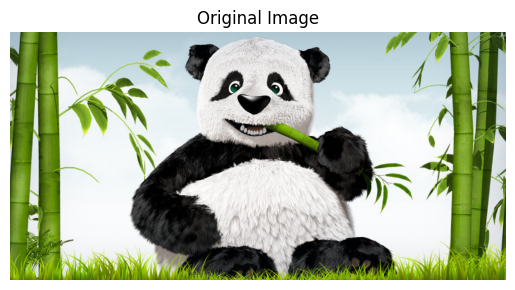

In [6]:
#Task 1
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/AI-ML/Worksheet1/panda.jpg")

img_array = np.array(img)
print("Shape:", img_array.shape)
print("Dtype:", img_array.dtype)

plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

Image.open() loads the image file. Then np.array() converts it into a 3D array with shape (height, width, 3), where the three channels represent Red, Green, and Blue. Each pixel has a value between 0 and 255.

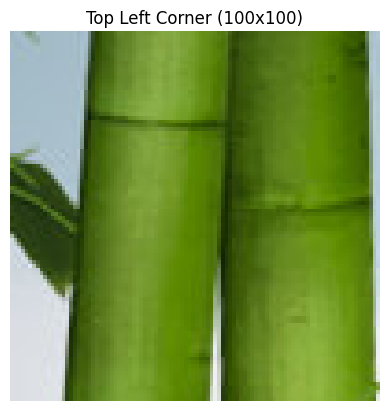

In [7]:
#Task2
top_left = img_array[0:100, 0:100, :]

plt.imshow(top_left)
plt.title("Top Left Corner (100x100)")
plt.axis("off")
plt.show()

NumPy indexing [0:100, 0:100] selects the first 100 rows and first 100 columns, which corresponds to the top-left part of the image.
img_array[:, :, 0] selects all rows and columns but only the red channel (index 0).
The cmap parameter in matplotlib adds a color tint (like red, green, or blue) to the grayscale intensity values. Without cmap, the image would simply appear in grayscale.

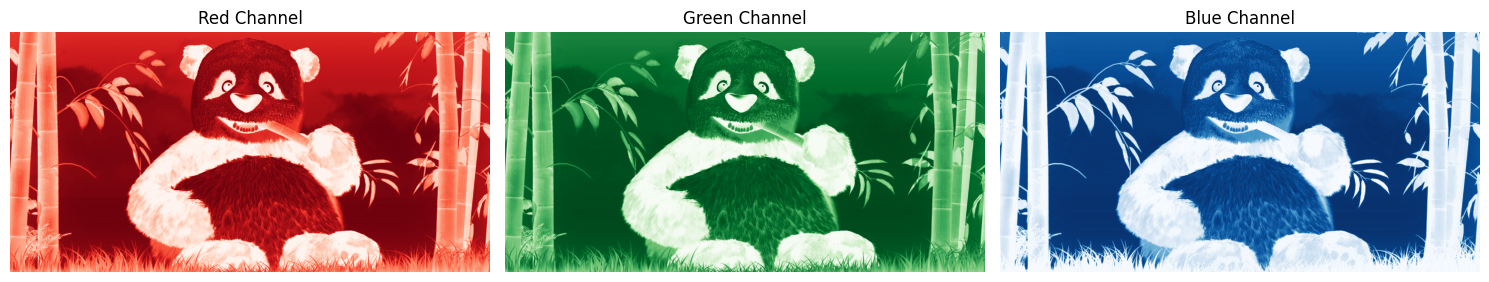

In [8]:
#Task3

red_channel   = img_array[:, :, 0]
green_channel = img_array[:, :, 1]
blue_channel  = img_array[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(red_channel,   cmap="Reds")
axes[0].set_title("Red Channel")
axes[0].axis("off")

axes[1].imshow(green_channel, cmap="Greens")
axes[1].set_title("Green Channel")
axes[1].axis("off")

axes[2].imshow(blue_channel,  cmap="Blues")
axes[2].set_title("Blue Channel")
axes[2].axis("off")

plt.tight_layout()
plt.show()

What’s happening here is that **all three color channels (R=210, G=210, B=210)** are set to the same value, which creates a **light gray color** because equal red, green, and blue values produce gray. The **`.copy()`** is also important because it makes a separate copy of the array; otherwise, the original **`img_array`** would be modified as well.


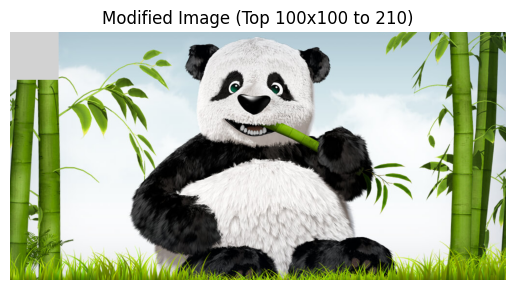

In [9]:
#Task4

modified = img_array.copy()

# Set all 3 channels of the top-left 100x100 to 210
modified[0:100, 0:100, :] = 210

plt.imshow(modified)
plt.title("Modified Image (Top 100x100 to 210)")
plt.axis("off")
plt.show()

**Ques 2**

In [10]:
IMAGE_PATH = "/content/drive/MyDrive/AI-ML/Worksheet1/tiger.jpg"

What happens here is that `.convert('L')` simply turns the image into **grayscale**. After that, the image is stored as a **2D array (height, width)** where each pixel has a value between **0 (black)** and **255 (white)**.


Shape: (388, 586)
Dtype: uint8


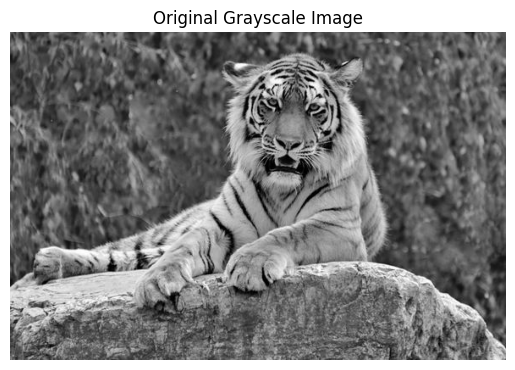

In [11]:
#Task1
# Load the image as grayscale
img = Image.open(IMAGE_PATH).convert('L')

# Convert to NumPy array
img_array = np.array(img)

print("Shape:", img_array.shape)
print("Dtype:", img_array.dtype)

plt.imshow(img_array, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

What happens here is that height // 2 finds the center row of the image. By slicing ±75 pixels around this center, it selects 150 pixels in total centered on that row.

Middle section shape: (150, 150)


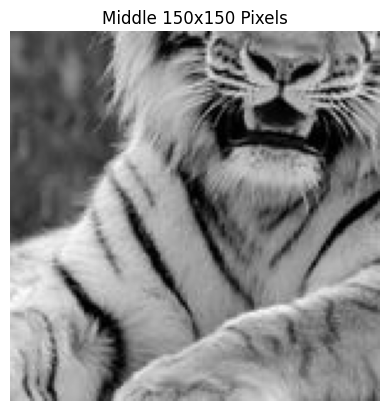

In [12]:
#Task2
height, width = img_array.shape

# Center coordinates
center_row = height // 2
center_col = width  // 2

middle = img_array[center_row - 75 : center_row + 75,
                   center_col - 75 : center_col + 75]
print("Middle section shape:", middle.shape)  # (150, 150)

plt.imshow(middle, cmap='gray')
plt.title("Middle 150x150 Pixels")
plt.axis("off")
plt.show()

What happens here is that a binary image is created, where each pixel becomes either pure black (0) or pure white (255). The function np.where(condition, value_if_true, value_if_false) provides a clean and efficient way to assign these values based on a specified condition.

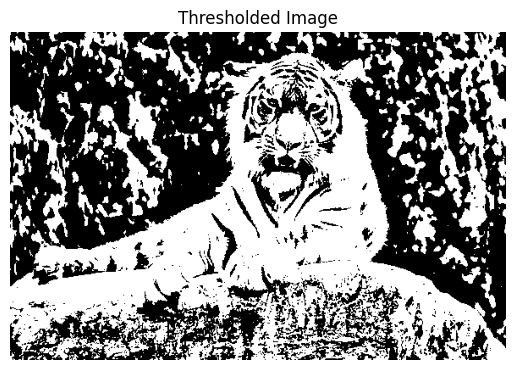

In [13]:
#Task3

thresholded = img_array.copy()
thresholded[thresholded < 100]  = 0
thresholded[thresholded >= 100] = 255

plt.imshow(thresholded, cmap='gray')
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

What happens here is that Pillow’s rotate() function rotates images counter-clockwise by default, so using -90 degrees results in a clockwise rotation. The parameter expand=True adjusts the canvas size so the entire rotated image fits without being cropped. In NumPy, setting k=3 rotates the image three times counter-clockwise, which is equivalent to one clockwise rotation.

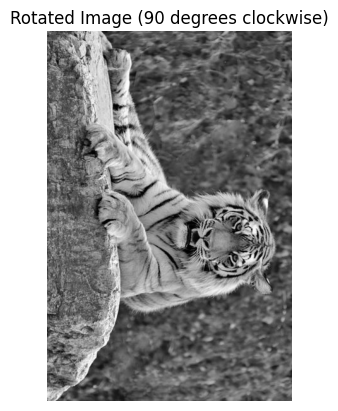

In [14]:
#Task4

img_rotated_pil = img.rotate(-90, expand=True)

plt.imshow(img_rotated_pil, cmap='gray')
plt.title("Rotated Image (90 degrees clockwise)")
plt.axis("off")
plt.show()

An RGB image contains three color channels. Because a grayscale image has the same value for red, green, and blue, the single grayscale channel is duplicated three times. The function np.stack(..., axis=-1) creates a new third axis, converting the array shape from (H, W) to (H, W, 3).

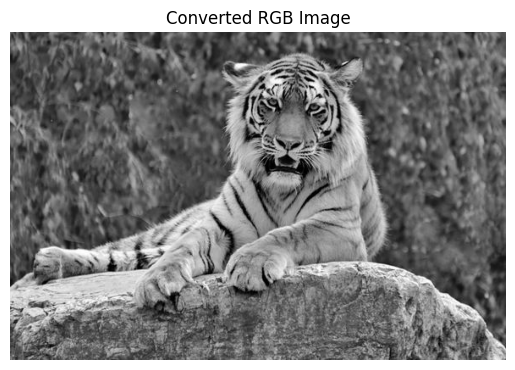

In [15]:
#Task5
img_rgb_pil = img.convert('RGB')
plt.imshow(img_rgb_pil)
plt.title("Converted RGB Image")
plt.axis("off")
plt.show()

**Ques 3**

In [16]:
#Step 1
# Convert to grayscale
img = Image.open("/content/drive/MyDrive/AI-ML/Worksheet1/panda.jpg").convert('L')
img_array = np.array(img, dtype=np.float64)

print("Image shape:", img_array.shape)

Image shape: (510, 1020)


In [17]:
# Subtract the mean of each column
mean = np.mean(img_array, axis=0)
centered = img_array - mean

print("Mean shape:", mean.shape)
print("Centered shape:", centered.shape)
print("Mean of centered (should be ~0):", np.abs(centered.mean()).round(10))

Mean shape: (1020,)
Centered shape: (510, 1020)
Mean of centered (should be ~0): 0.0


In [18]:
#Calculate the Covariance Matrix
n = centered.shape[0]   # number of rows
cov_matrix = (centered.T @ centered) / (n - 1)

print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (1020, 1020)


In [19]:
#Step2 - Eigen decomposition

# eigh is used for symmetric matrices
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# eigh returns in ASCENDING order — reverse to get descending
eigenvalues  = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)
print("Top 5 eigenvalues:", eigenvalues[:5].round(2))

Eigenvalues shape: (1020,)
Eigenvectors shape: (1020, 1020)
Top 5 eigenvalues: [1569783.88 1211636.16  392443.84  369437.56  294122.83]


80% variance explained by 8 components
90% variance explained by 18 components
95% variance explained by 35 components
99% variance explained by 113 components


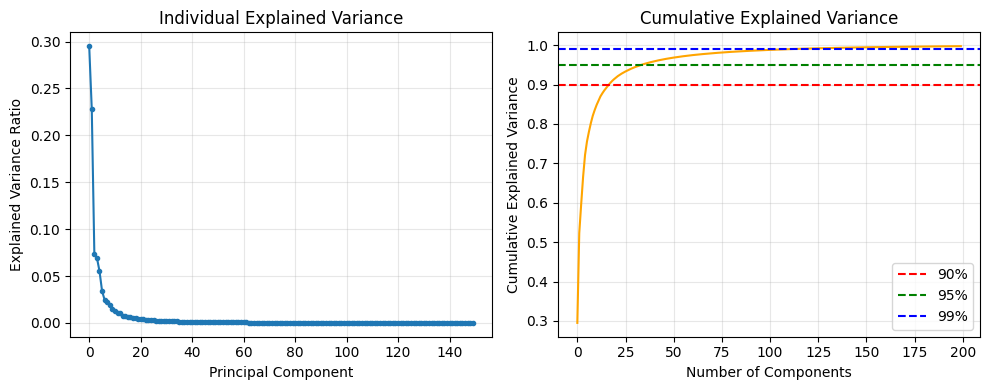

In [20]:
#Cumulative Explained Variance Plot

total_variance      = np.sum(eigenvalues)
explained_variance  = eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance)

for threshold in [0.80, 0.90, 0.95, 0.99]:
    k = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{int(threshold*100)}% variance explained by {k} components")

#for plotting
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(explained_variance[:150], marker='o', markersize=3)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Individual Explained Variance")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(cumulative_variance[:200], color='orange')
plt.axhline(y=0.90, color='r', linestyle='--', label='90%')
plt.axhline(y=0.95, color='g', linestyle='--', label='95%')
plt.axhline(y=0.99, color='b', linestyle='--', label='99%')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
#Step 3 - reconstruction function
def pca_reconstruct(centered_data, eigenvectors, mean, k):
    # Select top-k eigenvectors: shape (W, k)
    top_k_eigenvectors = eigenvectors[:, :k]

    # Step 1: Encode into k dimensions
    scores = centered_data @ top_k_eigenvectors

    # Step 2: Reconstruct/decode back to W dimensions
    reconstructed = scores @ top_k_eigenvectors.T

    # Step 3: Add mean back
    reconstructed = reconstructed + mean

    # Clip to valid pixel range [0, 255]
    reconstructed = np.clip(reconstructed, 0, 255)

    return reconstructed.astype(np.uint8)

In [23]:
#Step 4 - Experiment with different k vlaues

#Compare 4 different k values
k_values = [10, 20, 50, 100, 150]

# Pre-compute all for reconstruction
reconstructions = {}
for k in k_values:
    reconstructions[k] = pca_reconstruct(centered, eigenvectors, mean, k)
    var_explained = cumulative_variance[k-1] * 100
    print(f"k={k:4d} | Variance explained: {var_explained:.2f}%")

k=  10 | Variance explained: 83.50%
k=  20 | Variance explained: 91.33%
k=  50 | Variance explained: 96.75%
k= 100 | Variance explained: 98.77%
k= 150 | Variance explained: 99.44%


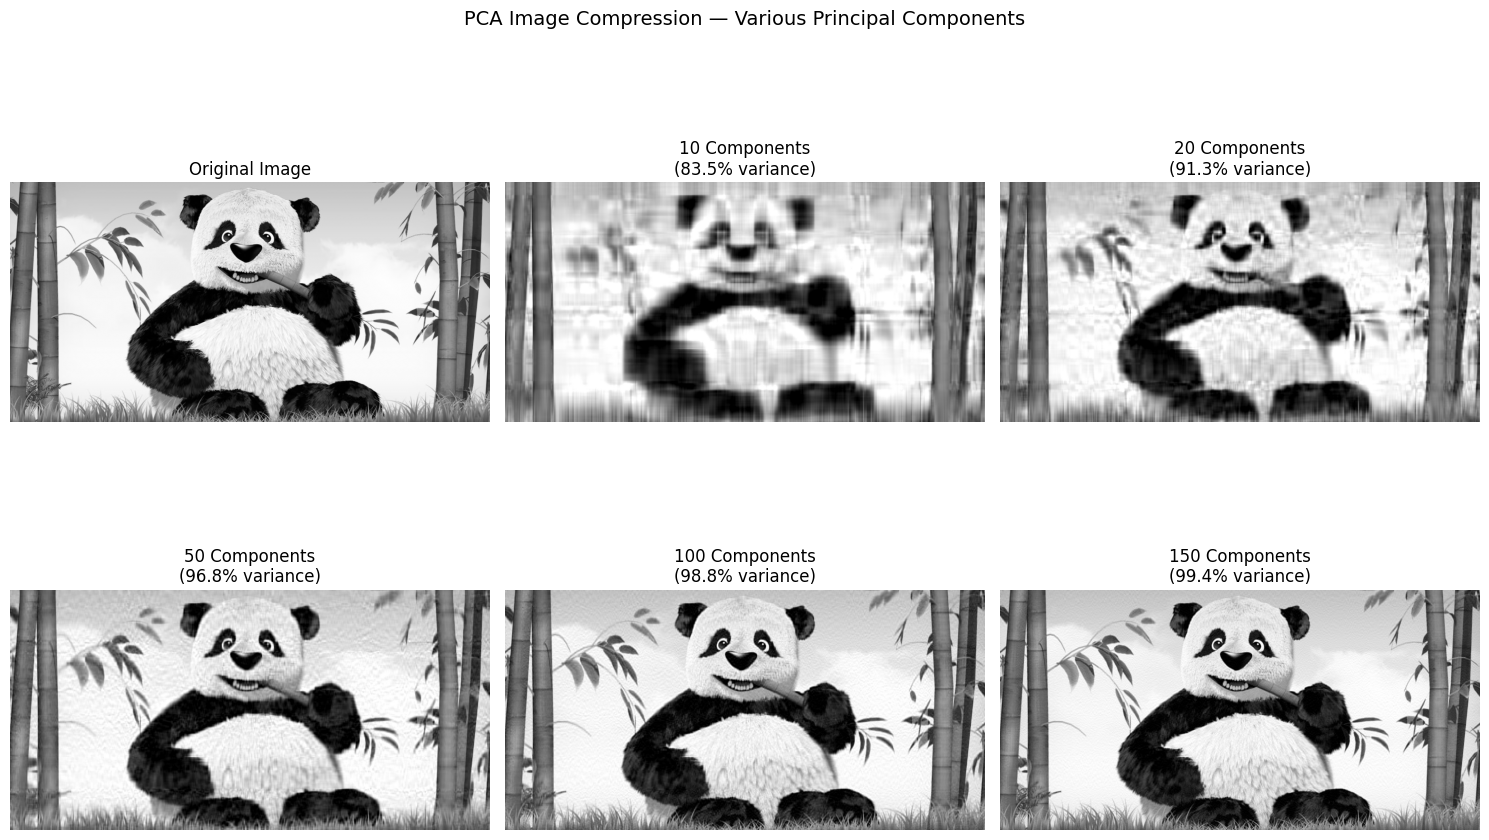

In [24]:
#Step5 - Displaying all results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original Image
axes[0][0].imshow(img_array.astype(np.uint8), cmap='gray')
axes[0][0].set_title("Original Image")
axes[0][0].axis("off")

# Reconstructed Image
positions = [(0,1), (0,2), (1,0), (1,1), (1,2)]
for (r, c), k in zip(positions, k_values):
    var = cumulative_variance[k-1] * 100
    axes[r][c].imshow(reconstructions[k], cmap='gray')
    axes[r][c].set_title(f"{k} Components\n({var:.1f}% variance)")
    axes[r][c].axis("off")

plt.suptitle("PCA Image Compression — Various Principal Components", fontsize=14)
plt.tight_layout()
plt.savefig("pca_compression_output.png", dpi=150)
plt.show()

In [25]:
#Step 6 - Evaluate with MSE and PSNR
def mse(original, reconstructed):
    return np.mean((original.astype(np.float64) - reconstructed.astype(np.float64)) ** 2)

def psnr(original, reconstructed):
    error = mse(original, reconstructed)
    if error == 0:
        return float('inf')
    return 10 * np.log10(255**2 / error)

# Compression ratio = original size / compressed size
H, W = img_array.shape
original_size = H * W

print(f"\n{'k':>6} | {'Variance':>10} | {'MSE':>10} | {'PSNR (dB)':>10} | {'Compression':>12}")
print("-" * 60)
for k in k_values:
    var    = cumulative_variance[k-1] * 100
    err    = mse(img_array, reconstructions[k])
    p      = psnr(img_array, reconstructions[k])

    # Compressed size = k*(H + W + 1) numbers stored instead of H*W
    comp   = original_size / (k * (H + W + 1))
    print(f"{k:>6} | {var:>9.2f}% | {err:>10.2f} | {p:>10.2f} | {comp:>10.2f}x")


     k |   Variance |        MSE |  PSNR (dB) |  Compression
------------------------------------------------------------
    10 |     83.50% |     833.62 |      18.92 |      33.98x
    20 |     91.33% |     438.00 |      21.72 |      16.99x
    50 |     96.75% |     165.53 |      25.94 |       6.80x
   100 |     98.77% |      62.87 |      30.15 |       3.40x
   150 |     99.44% |      29.05 |      33.50 |       2.27x
